# Rainbow (IQN) with CartPole-v1

This notebook loads [config_rainbow.yaml](config_rainbow.yaml) and trains the
`RainbowDQNAgent` on `CartPole-v1` — the Rainbow counterpart to the DQN baseline in
[exp1.ipynb](exp1.ipynb): same env, same normalisation, same training schedule, so the
two are directly comparable. Only the agent (and therefore the network wiring) changes.

Rainbow here = Double DQN + Dueling + Prioritised replay + Multi-step returns +
Distributional (**IQN**, in place of C51) + Noisy Nets. See
[src/agents/README.md](../../src/agents/README.md) for the full manual.

**Key wiring difference from the baseline.** The DQN notebook passes a whole
`QNetwork`. Rainbow instead takes only an **encoder** — the MLP trunk producing a
`(B, 128)` feature vector — and builds the dueling + noisy + IQN head *inside* the
agent. So `nn_extra_kwargs` carries encoder args only; the agent infers `feature_dim`
and `n_actions` itself.

## Imports

In [1]:
import sys, pathlib
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

SRC = pathlib.Path.cwd().parents[1] / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from experiment import load_config, build_env, build_agent, train, make_run_logger
from agents.rainbow_agent import RainbowDQNAgent
from analysis.registry import resolve_methods
from analysis.low_rank.rank import row_rank_property_check
from analysis.visualisations.heatmaps import plot_matrix_heatmap

## Reading the config file

Note the non-default filename — this experiment has two configs (`config.yaml` for the DQN baseline, `config_rainbow.yaml` here).

In [2]:
cfg = load_config("config_rainbow.yaml")   # loads yaml, resolves device, seeds torch/numpy
print("device:", cfg["experiment"]["_device"])
cfg

device: cuda


{'experiment': {'name': 'dqn_cartpole_rainbow',
  'seed': 52,
  'device': 'cuda',
  'save_artifacts': True,
  '_device': 'cuda'},
 'environment': {'name': 'CartPole-v1',
  'render_mode': None,
  'discrete_config': None,
  'normalise': {'action': {},
   'state': {'min': [-4.8, -10, -0.41887903, -10],
    'max': [4.8, 10, 0.41887903, 10]}},
  'clip': {'action': False,
   'state': {'min': [None, -100, None, -100], 'max': [None, 100, None, 100]}}},
 'network': {'hidden_sizes': [128, 128]},
 'agent': {'replay_buffer_capacity': 100000,
  'batch_size': 128,
  'nn_learning_rate': 0.0005,
  'discount_factor': 0.99,
  'n_step': 3,
  'n_quantiles': 32,
  'n_quantiles_target': 32,
  'n_quantiles_act': 32,
  'n_cos': 64,
  'head_hidden': 128,
  'huber_kappa': 1.0,
  'dueling': True,
  'noisy_sigma0': 0.5,
  'double': True,
  'per_alpha': 0.5,
  'per_beta_start': 0.4,
  'per_beta_increment': 1e-05,
  'per_eps': 1e-05,
  'TD_LR': 0.3,
  'buffer_util': 1,
  'gd_steps_ceil': 40,
  'grad_clip_norm': 10.

## Creating the Environment

In [3]:
env = build_env(cfg)
obs_dim = env.observation_space.shape[0]
n_actions = env.action_space.n
print("obs_dim:", obs_dim, "n_actions:", n_actions)

obs_dim: 4 n_actions: 2


## Encoder (MLP trunk only)

For Rainbow the externally-supplied network is just the **encoder** — the baseline's
MLP with the Q-head removed. Everything Rainbow-specific (the cosine-τ IQN embedding,
the dueling value/advantage streams, the `NoisyLinear` layers) is built by
`RainbowDQNAgent` around it (see
[src/agents/rainbow_agent.py](../../src/agents/rainbow_agent.py)). The head width is
`agent.head_hidden` in the config.

In [4]:
class MLPEncoder(nn.Module):
    """Maps a state (obs_dim,) -> features (B, hidden_sizes[-1]).
    RainbowDQNAgent builds the dueling + noisy + IQN head around this."""
    def __init__(self, in_dim, hidden_sizes=(128, 128)):
        super().__init__()
        layers, last = [], in_dim
        for h in hidden_sizes:
            layers += [nn.Linear(last, h), nn.ReLU()]
            last = h
        self.net = nn.Sequential(*layers)
        self.feature_dim = last

    def forward(self, x):
        return self.net(x)

## Creating the Agent

`build_agent` takes an optional `agent_cls` (default `QAgent`); pass
`RainbowDQNAgent` to build the Rainbow benchmark. `nn_extra_kwargs` carries **encoder
args only**; every Rainbow hyperparameter comes from `cfg["agent"]`.

In [5]:
nn_extra_kwargs = {"in_dim": obs_dim, "hidden_sizes": cfg["network"]["hidden_sizes"]}   # encoder args only
agent = build_agent(cfg, env, MLPEncoder, nn_extra_kwargs, agent_cls=RainbowDQNAgent)

## Analysis (Low Rank)

The Hankel sweep runs every `ep_freq` episodes via the `analysis.hankel_sweep` config
block (dispatched inside the training loop). Because Rainbow is genuinely **dueling**,
`value_advantage` exposes learned V(s) and mean-centred A(s,·) streams — so the Hankel
**A** trace is a real signal here, not the trivially rank-deficient `Q − max Q` of the
baseline's vanilla head. Run artifacts land under `runs/<timestamp>/` when
`experiment.save_artifacts` is set.

In [6]:
# Pass the non-default config filename so the frozen snapshot is config_rainbow.yaml.
logger = make_run_logger(cfg, config_path="config_rainbow.yaml")
if logger:
    print("run artifacts ->", logger.dir)

run artifacts -> /home/souparna/Low-Rank-RL-TL/experiments/dqn_cartpole/runs/20260715-183153


## Agent Training

In [7]:
rewards = train(cfg, agent, env, run_logger=logger)

  0%|          | 0/1500 [00:00<?, ?it/s]

episode 0 avg_rewarg: 17.0
****************************Q-function****************************
eff_rank: 1, stable_rank: 1.00, spikiness: 1.42, shape: (4096, 2), non-zero rows :4096, non-zero cols:2
top-r leverage spread: row min=0.0001792 max=0.0003784 (uniform 0.0002441) | col min=0.3853 max=0.6147 (uniform 0.5)
coherence score: row=1.55 col=1.229


  1%|▏         | 22/1500 [00:01<00:51, 28.76it/s]

episode 10 avg_rewarg: 17.7
episode 20 avg_rewarg: 20.9


  3%|▎         | 41/1500 [00:01<00:29, 49.38it/s]

...

episode 750 avg_rewarg: 493.9
****************************Q-function****************************
eff_rank: 2, stable_rank: 1.22, spikiness: 4.08, shape: (4096, 2), non-zero rows :4096, non-zero cols:2
top-r leverage spread: row min=1.624e-09 max=0.002671 (uniform 0.0002441) | col min=0.5 max=0.5 (uniform 0.5)
coherence score: row=10.94 col=1


 51%|█████     | 761/1500 [05:55<07:44,  1.59it/s]

episode 760 avg_rewarg: 490.0


 51%|█████     | 761/1500 [05:56<05:45,  2.14it/s]

Average trajectory (episode total) reward for 50 episodes is 476.06
Triggering Early Stopping !!
run artifacts saved under /home/souparna/Low-Rank-RL-TL/experiments/dqn_cartpole/runs/20260715-183153


## Training and Analysis Plots

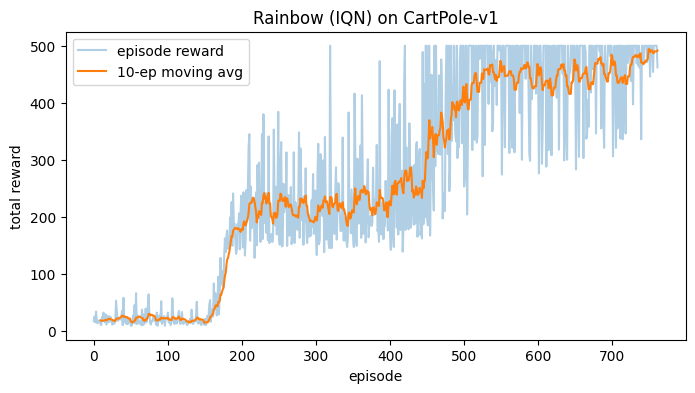

In [8]:
rewards = np.asarray(rewards, dtype=float)
plt.figure(figsize=(8, 4))
plt.plot(rewards, alpha=0.35, label="episode reward")
if len(rewards) >= 10:
    k = 10
    ma = np.convolve(rewards, np.ones(k) / k, mode="valid")
    plt.plot(range(k - 1, len(rewards)), ma, label=f"{k}-ep moving avg")
plt.xlabel("episode"); plt.ylabel("total reward"); plt.title("Rainbow (IQN) on CartPole-v1")
plt.legend()
if logger:
    plt.savefig(logger.dir / "reward_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## Post-training analysis

Same as the baseline: run the generic per-matrix methods (`q_matrix_dqn`) on the final
policy, showing heatmap + spectrum for each. Hankel already ran during training.

Q-function


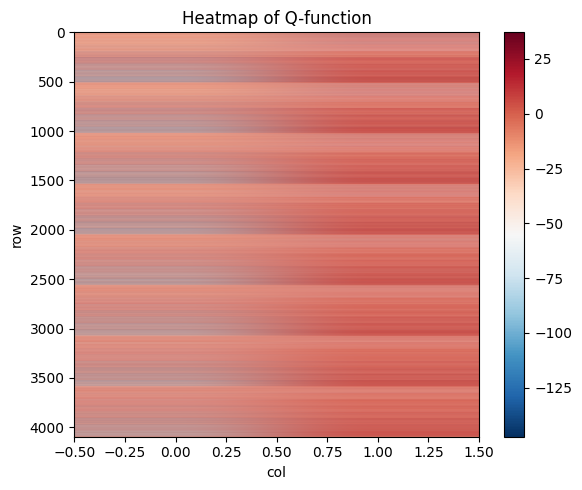

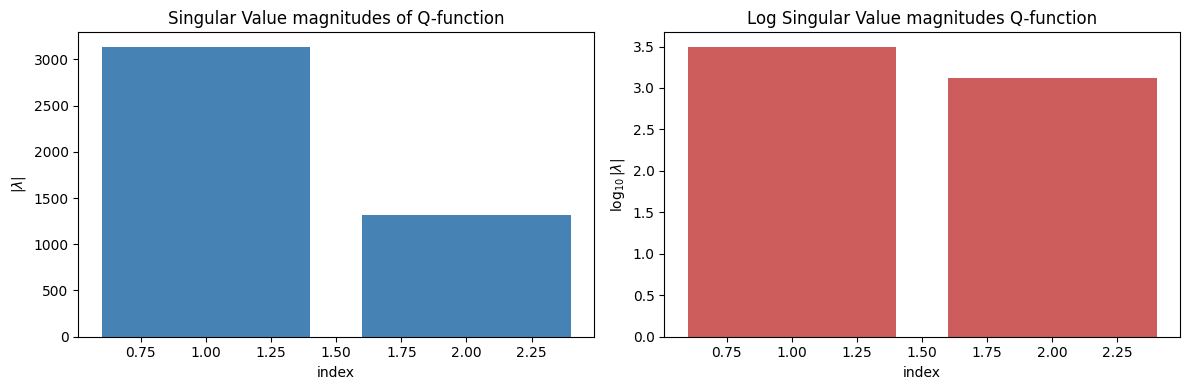

eff_rank: 2, stable_rank: 1.18, spikiness: 3.92, shape: (4096, 2), non-zero rows :4096, non-zero cols:2
top-r leverage spread: row min=9.057e-09 max=0.003137 (uniform 0.0002441) | col min=0.5 max=0.5 (uniform 0.5)
coherence score: row=12.85 col=1


In [9]:
methods = resolve_methods(cfg["analysis"].get("methods", []) + cfg["analysis"].get("post_methods", []))
for method, names in methods:
    results = method(agent=agent, env=env)
    if not isinstance(results, tuple):
        results = (results,)
    for matrix, name in zip(results, names):
        print(name)
        plot_matrix_heatmap(matrix, name, save_to=logger.figure_path(f"{name} heatmap") if logger else None)
        r, sr, spk, shape, irs, ics, rc, cc, nzr, nzc = row_rank_property_check(matrix, name, save_to=logger.figure_path(name) if logger else None)
        print(f"eff_rank: {r}, stable_rank: {sr:.2f}, spikiness: {spk:.2f}, shape: {shape}, non-zero rows :{nzr}, non-zero cols:{nzc}")
        print(f"top-r leverage spread: row min={irs.min():.4g} max={irs.max():.4g} (uniform {1.0/shape[0]:.4g}) | col min={ics.min():.4g} max={ics.max():.4g} (uniform {1.0/shape[1]:.4g})")
        print(f"coherence score: row={rc:.4g} col={cc:.4g}")

## Greedy rollout video

Record one greedy (`act_greedy`) episode of the trained agent and display it inline.
The greedy action still uses the noisy weights (exploration is baked into the net).

In [10]:
from analysis.visualisations.rollout_video import record_greedy_episode
from IPython.display import Video
import glob

video_dir = "videos"
eval_env = build_env(cfg, render_mode="rgb_array")
prefix = record_greedy_episode(agent, eval_env, video_dir, episode=0, seed=cfg["experiment"]["seed"])
mp4 = sorted(glob.glob(f"{video_dir}/{prefix}-*.mp4"))[-1]
print("saved:", mp4)
Video(mp4, embed=True)

/home/souparna/Low-Rank-RL-TL/.venv/lib/python3.12/site-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /home/souparna/Low-Rank-RL-TL/experiments/dqn_cartpole/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


saved: videos/ep0-episode-0.mp4
